FASE 1: EXPLORACION Y LIMPIEZA.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
df_flight = pd.read_csv("files/Customer Flight Activity.csv") # ABRO AMBOS DATAFRAME PARA VER UN POCO SU COMPOSICION CON UN INFO DONDE VEO EXTENSION DE ESTOS VALORES NULOS Y TIPO DE DATO.
df_loyalty = pd.read_csv("files/Customer Loyalty History.csv")
df_flight.info()
df_flight.head().T


<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


,0,1,2,3,4
Loyalty Number,100018.0,100102.0,100140.0,100214.0,100272.0
Year,2017.0,2017.0,2017.0,2017.0,2017.0
Month,1.0,1.0,1.0,1.0,1.0
Flights Booked,3.0,10.0,6.0,0.0,0.0
Flights with Companions,0.0,4.0,0.0,0.0,0.0
Total Flights,3.0,14.0,6.0,0.0,0.0
Distance,1521.0,2030.0,1200.0,0.0,0.0
Points Accumulated,152.0,203.0,120.0,0.0,0.0
Points Redeemed,0.0,0.0,0.0,0.0,0.0
Dollar Cost Points Redeemed,0.0,0.0,0.0,0.0,0.0


In [3]:
df_flight.duplicated().sum()# veo que todos los duplicados estan en este dataset 

np.int64(1864)

In [4]:
df_flight[df_flight.duplicated(keep=False)]

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
41,101902,2017,1,0,0,0,0,0.0,0,0
42,101902,2017,1,0,0,0,0,0.0,0,0
226,112142,2017,1,0,0,0,0,0.0,0,0
227,112142,2017,1,0,0,0,0,0.0,0,0
477,126100,2017,1,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
405111,971370,2018,12,0,0,0,0,0.0,0,0
405409,988392,2018,12,0,0,0,0,0.0,0,0
405410,988392,2018,12,0,0,0,0,0.0,0,0
405436,989528,2018,12,0,0,0,0,0.0,0,0


In [5]:
df_flight[df_flight.duplicated()].shape 

(1864, 10)

EFECTIVAMENTE AQUI ESTAN TAMBIEN LAS COPIAS EN ESTE DATASET

In [6]:
df_flight=df_flight.drop_duplicates()

In [7]:
df_flight.duplicated().sum()

np.int64(0)

Me llama la atencion que Points Accumulated este como float.

In [8]:

df_loyalty.info()
df_loyalty.head().T

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

,0,1,2,3,4
Loyalty Number,480934,549612,429460,608370,530508
Country,Canada,Canada,Canada,Canada,Canada
Province,Ontario,Alberta,British Columbia,Ontario,Quebec
City,Toronto,Edmonton,Vancouver,Toronto,Hull
Postal Code,M2Z 4K1,T3G 6Y6,V6E 3D9,P1W 1K4,J8Y 3Z5
Gender,Female,Male,Male,Male,Male
Education,Bachelor,College,College,College,Bachelor
Salary,83236.0,NaN,NaN,NaN,103495.0
Marital Status,Married,Divorced,Single,Single,Married
Loyalty Card,Star,Star,Star,Star,Star


Tras la primera exploracion rapida de ambos dataframe, en el primer df_flight no hay valores nulos, y en el segundo tenemos 3 columnas con valores nulos, 2 de ellas con un alto valor de nulos.Tras analizar los duplicados en el primer dataset de df_flight se encuentran 1864 duplicados voy a limpiarlos antes de unir.Procedo a unir ambos mediante el metodo merge lef join para mantener todos los registros de vuelos e incorporar la informacion de clientes sin perdida de datos, unimos por la columna en comun "Loyalty Number", descarto inner join ya que si no perderiamos datos y lo que queremos es ampliar datos del cliente en un solo dataframe.

In [9]:
df_loyalty.duplicated().sum() #compruebo que se eliminaron los duplicados.

np.int64(0)

In [10]:
#analizamos los nulos en el dataframe de origen,la columna salary ya que los otros nulos ya tengo claro que hacer con el
df_loyalty["Salary"].isna().mean() #tenemos un 0.25% de nulos,vamos a ver que representa esta columna tambien para nuestro analisis.

np.float64(0.25321144769074505)

In [11]:
df_loyalty["Salary"].describe()#aqui coomo contemple arriba vay valores negativos, y mucha diferencia desde el 75% al maximo se ven outliners.

count     12499.000000
mean      79245.609409
std       35008.297285
min      -58486.000000
25%       59246.500000
50%       73455.000000
75%       88517.500000
max      407228.000000
Name: Salary, dtype: float64

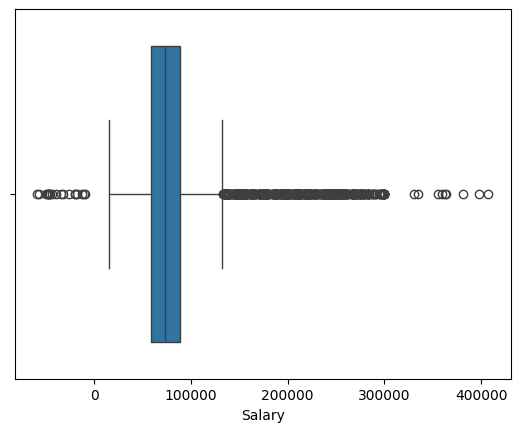

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_loyalty["Salary"])
plt.show()

#se detecta que hay numerosos outliners indica valor4es extremos de salarios con lo que distorsiona mas la media, la mayoria se concentran en un rango , voy analizar los valores negativos a ver de cuantos se trata.

In [13]:
df_loyalty[df_loyalty["Salary"]<0] # no estan siguiendo un patron tipico ya que vienen de distintos grupos, son cantidades grandes parece mas fallo de introduccion de datos voy a optar por tratarlos como nulos.

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
1082,542976,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830.0,Divorced,Star,24127.50,2018 Promotion,2018,3,NaN,NaN
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497.0,Married,Aurora,9453.00,2018 Promotion,2018,3,NaN,NaN
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.0,Single,Nova,4787.81,2018 Promotion,2018,3,NaN,NaN
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962.0,Married,Star,2402.33,2018 Promotion,2018,3,NaN,NaN
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325.0,Single,Star,2893.74,2018 Promotion,2018,3,NaN,NaN
4712,491242,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234.0,Married,Star,7597.91,2018 Promotion,2018,3,NaN,NaN
6560,115505,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605.0,Married,Nova,5860.17,2018 Promotion,2018,4,NaN,NaN
6570,430398,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534.0,Married,Nova,49423.80,2018 Promotion,2018,3,NaN,NaN
7373,152016,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486.0,Married,Aurora,5067.21,2018 Promotion,2018,2,NaN,NaN
8576,194065,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911.0,Married,Nova,2888.85,2018 Promotion,2018,2,NaN,NaN


aunque he comparado los datos negativos que pueden coincidir con los valores reales,en un principio decidi tras analizarlos, imputarlos como nulos pero ahora voya  barajar otra hipotesis que es que sean positivos, como veo que todos los que tienen salario negativo a nivel education son de bachiller voy a ver que rangos salariales mas o menos se barajan para ver si coinciden y coonfirmar un poco mas la teoria de que en realidad son valores positivos.

In [14]:
df_loyalty[(df_loyalty["Education"] == "Bachelor") & (df_loyalty["Salary"] > 0)]["Salary"].describe()

count     10456.000000
mean      72645.926262
std       16590.634159
min       15609.000000
25%       58715.500000
50%       72026.000000
75%       85848.000000
max      105563.000000
Name: Salary, dtype: float64

In [ ]:
#df_loyalty.loc[df_loyalty["Salary"] < 0, "Salary"] = None #procedo a convertir los valores negativos a nulos 

In [15]:
df_loyalty[(df_loyalty["Education"] == "Bachelor") & (df_loyalty["Salary"] < 0)]["Salary"].describe()

count       19.000000
mean    -34786.052632
std      16080.943973
min     -58486.000000
25%     -46576.500000
50%     -39503.000000
75%     -19328.500000
max      -9081.000000
Name: Salary, dtype: float64

In [16]:
df_loyalty["Salary"].isna().mean()# tras lo analizado hasta el momento se detecta como mejor recurso imputar por la mediana ya que la media esta inflada,paso a comprobar la mediana de salario del nivel educativo para ver si se puede afinar mas.

np.float64(0.25321144769074505)

In [ ]:
df_loyalty.groupby("Education")["Salary"].median() #acabo de ver que en college no tenemos mediana, voy a investigar mas.// no tenemos valores de salario en este grupo!

Education
Bachelor                 72026.0
College                      NaN
Doctor                  182143.5
High School or Below     61928.0
Master                  105487.0
Name: Salary, dtype: float64

In [ ]:
df_loyalty[df_loyalty["Education"] == "College"] #este grupo no tiene ningun dato de salario.

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
6,927943,Canada,Ontario,Toronto,P5S 6R4,Female,College,NaN,Single,Star,3857.95,Standard,2014,6,NaN,NaN
13,988178,Canada,Quebec,Montreal,H4G 3T4,Male,College,NaN,Single,Star,3871.07,Standard,2013,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16721,632951,Canada,Alberta,Edmonton,T9G 1W3,Female,College,NaN,Married,Star,44771.30,Standard,2018,7,NaN,NaN
16727,546773,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Married,Star,52811.49,Standard,2015,9,NaN,NaN
16731,900501,Canada,Ontario,Sudbury,M5V 1G5,Male,College,NaN,Single,Star,61134.68,Standard,2012,9,NaN,NaN
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN


In [ ]:
df_new = pd.merge(df_flight, df_loyalty, on="Loyalty Number", how="left") #realizamos el merge de ambos dataframe.

In [31]:
df_new.head().T

,0,1,2,3,4
Loyalty Number,100018,100102,100140,100214,100272
Year,2017,2017,2017,2017,2017
Month,1,1,1,1,1
Flights Booked,3,10,6,0,0
Flights with Companions,0,4,0,0,0
Total Flights,3,14,6,0,0
Distance,1521,2030,1200,0,0
Points Accumulated,152.0,203.0,120.0,0.0,0.0
Points Redeemed,0,0,0,0,0
Dollar Cost Points Redeemed,0,0,0,0,0


In [32]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               403760 non-null  int64  
 1   Year                         403760 non-null  int64  
 2   Month                        403760 non-null  int64  
 3   Flights Booked               403760 non-null  int64  
 4   Flights with Companions      403760 non-null  int64  
 5   Total Flights                403760 non-null  int64  
 6   Distance                     403760 non-null  int64  
 7   Points Accumulated           403760 non-null  float64
 8   Points Redeemed              403760 non-null  int64  
 9   Dollar Cost Points Redeemed  403760 non-null  int64  
 10  Country                      403760 non-null  str    
 11  Province                     403760 non-null  str    
 12  City                         403760 non-null  str    
 13  Postal Cod

In [33]:
df_new.isna().sum()

Loyalty Number                      0
Year                                0
Month                               0
Flights Booked                      0
Flights with Companions             0
Total Flights                       0
Distance                            0
Points Accumulated                  0
Points Redeemed                     0
Dollar Cost Points Redeemed         0
Country                             0
Province                            0
City                                0
Postal Code                         0
Gender                              0
Education                           0
Salary                         102260
Marital Status                      0
Loyalty Card                        0
CLV                                 0
Enrollment Type                     0
Enrollment Year                     0
Enrollment Month                    0
Cancellation Year              354110
Cancellation Month             354110
dtype: int64

In [34]:
round(df_new.isnull().mean()*100,2).sort_values(ascending=False)

Cancellation Month             87.70
Cancellation Year              87.70
Salary                         25.33
Year                            0.00
Flights with Companions         0.00
Total Flights                   0.00
Month                           0.00
Flights Booked                  0.00
Loyalty Number                  0.00
Points Redeemed                 0.00
Points Accumulated              0.00
Distance                        0.00
Dollar Cost Points Redeemed     0.00
City                            0.00
Postal Code                     0.00
Province                        0.00
Country                         0.00
Education                       0.00
Gender                          0.00
Marital Status                  0.00
Loyalty Card                    0.00
Enrollment Type                 0.00
CLV                             0.00
Enrollment Month                0.00
Enrollment Year                 0.00
dtype: float64

el porcentaje de nulos de esas columnas son muy elevados procedo a investigar un poco mas a fondo, la de salario esta en un punto intermedio para estudiar. paso a ver si hay duplicados.

In [35]:
df_new.duplicated().sum() # voy a investigar el origen de estos porque hay bastantes.

np.int64(0)

In [36]:
round(df_new.duplicated().mean()*100,2) #es un 0.46% de duplicados no es un porcentaje tan alto ahora.EN LA FASE 2 PROCEDO A DECIDIR QUE HACER.

np.float64(0.0)

In [37]:
df_new[df_new.duplicated()]

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,...,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month


In [38]:
df_new[df_new.duplicated(keep=False)] #aqui procedo a ver tqambien sus copias y efectivamente son duplicados

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,...,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month


In [39]:
df_new.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
Flights with Companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
Total Flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
Distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
Points Accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
Points Redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00


Salary tiene valores negativos en el minimo es un poco raro,y el maximo es muy alto comparado con el 75% pinta outliner,en flight y flight booked tambien hay diferencia de la media y la mediana, frente  al maximo con lo que tambien se intuye presencia de outliners.

In [40]:
df_new.nunique() #aqui procedo a detectar columnas redundantes que tengan solo un unico valor en mi dataframe y  deetecto que country solo tiene uno, con lo que no aporta informacion importante.

Loyalty Number                 16737
Year                               2
Month                             12
Flights Booked                    22
Flights with Companions           12
Total Flights                     33
Distance                        4746
Points Accumulated              1549
Points Redeemed                  587
Dollar Cost Points Redeemed       49
Country                            1
Province                          11
City                              29
Postal Code                       55
Gender                             2
Education                          5
Salary                          5890
Marital Status                     3
Loyalty Card                       3
CLV                             7984
Enrollment Type                    2
Enrollment Year                    7
Enrollment Month                  12
Cancellation Year                  6
Cancellation Month                12
dtype: int64

In [41]:
df_new["Country"].value_counts() # canada voy a proceder a eliminarla en la fase 2 ya que no me aporta ningun valor adicional.

Country
Canada    403760
Name: count, dtype: int64

In [42]:
df_new.select_dtypes(include="str").columns

Index(['Country', 'Province', 'City', 'Postal Code', 'Gender', 'Education',
       'Marital Status', 'Loyalty Card', 'Enrollment Type'],
      dtype='str')

In [43]:
for col in df_new.select_dtypes(include="str"): # aqui perocedo a ver los valores de mis columnas de string, esta todo normalizado, veo tambien datos como que hay mas casados que solteros, a nivel educacion los que mas predominarn son los de bachillers, hay mas mujeres aunque no hay mucha diferencia.
    print(f"\n{col}")
    print(df_new[col].value_counts())


Country
Country
Canada    403760
Name: count, dtype: int64

Province
Province
Ontario                 130258
British Columbia        106442
Quebec                   79573
Alberta                  23360
Manitoba                 15900
New Brunswick            15352
Nova Scotia              12507
Saskatchewan              9861
Newfoundland              6244
Yukon                     2679
Prince Edward Island      1584
Name: count, dtype: int64

City
City
Toronto           80775
Vancouver         62314
Montreal          49687
Winnipeg          15900
Whistler          13994
Halifax           12507
Ottawa            12262
Edmonton          11768
Trenton           11710
Quebec City       11698
Dawson Creek      10725
Fredericton       10266
Regina             9861
Kingston           9652
Tremblant          9576
Victoria           9444
Hull               8612
West Vancouver     7831
St. John's         6244
Thunder Bay        6171
Sudbury            5493
Moncton            5086
Calgary        

In [44]:
#procedo analizar las columnas numericas.
df_new.select_dtypes(include=["int64", "float64"]).columns

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed',
       'Salary', 'CLV', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='str')

In [45]:
df_new.dtypes #aqui he visto que  cancellacion year y month es float por la presencia de nulos esta en float deberia ser int ya que los años y meses  se expresan en enteros normalment pero aun no voy a cambiar nada porque quiero imvestigar la presencia en tema de nulos.

Loyalty Number                   int64
Year                             int64
Month                            int64
Flights Booked                   int64
Flights with Companions          int64
Total Flights                    int64
Distance                         int64
Points Accumulated             float64
Points Redeemed                  int64
Dollar Cost Points Redeemed      int64
Country                            str
Province                           str
City                               str
Postal Code                        str
Gender                             str
Education                          str
Salary                         float64
Marital Status                     str
Loyalty Card                       str
CLV                            float64
Enrollment Type                    str
Enrollment Year                  int64
Enrollment Month                 int64
Cancellation Year              float64
Cancellation Month             float64
dtype: object

CONCLUSION FASE 1. En un primer momento se analizaron ambos dataframe con un info para comprobar extension presencia de nulos, y tipo de texto procedi a unir ambos y despues de empezar a analizar mas profundamente este me di cuenta de la presencia de duplicados con lo que procedi a analizarlos por separado y comprobe que solo estaban en 1 de ellos, asi como los  nulos, se encuentra tambien una columna duplicada, se analizan tipos de dato,durante esta fase primero se hizo un enfoque rapido general y luego se profundizo analizando luego detalles de cada dataset por separado.

FASE 2. LIMPIEZA.

HE procedido a eliminar los duplicados, antes de tomar esta decision he comprobado los duplicados de ambos dataset por separando donde se ve que los duplicados solo estan presentes en uno, con lo que se estudian se comprueban que son duplicados y procedo a eliminarlos antes del merge, a si mismo se detecta que respecto a los valores nulos solo estan presentes en un dataset tambien con lo que se estudiaran antes de su merge, las columnas, cancellation month y cancellation year a pesar de tener un numero alto de nulos tiene logica ya que es señal que el cliente sigue activo con su membresia.Procedo a eliminar una columna redundante que no aporta informacion adicional a nuestro analisis, que es la columna de contry ya que todos los registro constituyen a 1 mismo(Canada),se procede analizar la columna salary para entenderla mejor y ver que hacer con esos nulos, procedo analizarla en su dataframe original de donde proviene para a la hora de el merge que este lo mas limpio posible.Se estan haciendo los siguientes cambios y comprobaciones en las celdas usadas en la fase de eda para no duplicar celdas constantemente.Algunas celdas como las de duplicado de el dataframe convinado ya se quedan sin sentido pero en un primer momento se usaron para las primeras comprobaciones del analisis con lo que las dejo para dar sentido a este.